# Проект: Прогнозирование кредитного дефолта с использованием методов машинного обучения

## Тема проекта
**"Разработка системы оценки кредитного риска на основе машинного обучения с обработкой дисбаланса классов"**

## Полное описание проекта

### Проблематика
Банки и финансовые организации сталкиваются с проблемой невозврата кредитов, что приводит к значительным финансовым потерям. Традиционные методы оценки кредитоспособности часто оказываются недостаточно точными, особенно при работе с нестандартными клиентами или в условиях экономической нестабильности.

### Цель проекта
Разработать модель машинного обучения, способную:
1. Точно прогнозировать вероятность дефолта по кредиту
2. Эффективно работать с сильным дисбалансом классов (91.3% "хороших" заемщиков vs 8.7% "проблемных")
3. Обеспечивать интерпретируемость результатов для кредитных аналитиков

### Данные
Используется датасет Home Credit Default Risk с Kaggle, содержащий:
- 2000 аннотированных кредитных заявок
- 122 признака (демографические, финансовые, кредитная история)
- Целевая переменная: факт дефолта (1) или своевременного погашения (0)

### Методы решения
1. **Предобработка данных**:
   - Заполнение пропусков
   - Стандартизация числовых признаков
   - One-Hot Encoding категориальных переменных

2. **Борьба с дисбалансом**:
   - Параметр scale_pos_weight в XGBoost
   - Метрики, устойчивые к дисбалансу (ROC-AUC)
   - Анализ precision-recall

3. **Используемые модели**:
   ```python
   models = {
       "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
       "Random Forest": RandomForestClassifier(class_weight='balanced'),
       "XGBoost": xgb.XGBClassifier(scale_pos_weight=10.5),
       "Optimized XGBoost": # с параметрами от Optuna
   }

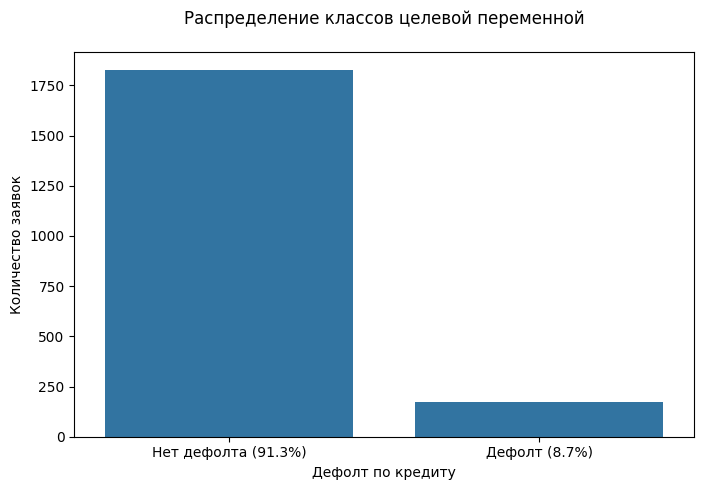

In [53]:
plt.figure(figsize=(8,5))
sns.countplot(x='TARGET', data=df)
plt.title('Распределение классов целевой переменной', pad=20)
plt.xlabel('Дефолт по кредиту')
plt.ylabel('Количество заявок')
plt.xticks([0,1], ['Нет дефолта (91.3%)', 'Дефолт (8.7%)'])
plt.show()

#Ход работы

  Импортируются основные библиотеки, которые используются в дальнейшем для анализа, обучения моделей и обработки данных.

  Создается папка models, в которой будут сохраняться обученные модели.



In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, roc_curve
from sklearn.inspection import permutation_importance
import xgboost as xgb
import shap
import optuna
import warnings
from scipy import stats
import os
import pickle

warnings.filterwarnings('ignore')
os.makedirs("models", exist_ok=True)


  Функция basic_data_analysis выполняет базовый анализ:

- Проверка на пропуски и вывод их количества.

- Описание диапазонов для числовых данных.

- Описание количества уникальных значений для категориальных признаков.

- Вывод распределения целевой переменной TARGET, если она присутствует в данных.



In [11]:
def basic_data_analysis(df):
    print("🔍 Базовый анализ данных:")

    # Пропуски
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if not missing.empty:
        print("\n📉 Пропущенные значения:")
        print(missing.sort_values(ascending=False))
    else:
        print("\n✅ Нет пропущенных значений.")

    # Диапазоны
    print("\n📊 Диапазоны числовых признаков:")
    numeric = df.select_dtypes(include=["int64", "float64"])
    print(numeric.describe().T[["min", "max"]])

    # Категориальные
    print("\n🔡 Категориальные признаки:")
    categorical = df.select_dtypes(include="object")
    for col in categorical.columns:
        print(f"{col}: {df[col].nunique()} уникальных значений")

    # Таргет
    if "TARGET" in df.columns:
        print("\n🎯 Распределение таргета:")
        print(df["TARGET"].value_counts(normalize=True).round(3))


агружаются данные из файла CSV (application.csv) и выбирается случайная выборка из 2000 строк для работы.

Целевая переменная (TARGET) отделяется от признаков, которые остаются в переменной X.

Определяются числовые и категориальные признаки для последующей обработки.

In [12]:
df = pd.read_csv("application_train.csv").sample(n=2000, random_state=42)
basic_data_analysis(df)

y = df["TARGET"]
X = df.drop(columns=["TARGET", "SK_ID_CURR"])

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()


🔍 Базовый анализ данных:

📉 Пропущенные значения:
COMMONAREA_AVG              1415
COMMONAREA_MODE             1415
COMMONAREA_MEDI             1415
NONLIVINGAPARTMENTS_AVG     1410
NONLIVINGAPARTMENTS_MODE    1410
                            ... 
OBS_30_CNT_SOCIAL_CIRCLE      10
OBS_60_CNT_SOCIAL_CIRCLE      10
DEF_60_CNT_SOCIAL_CIRCLE      10
EXT_SOURCE_2                   4
AMT_GOODS_PRICE                3
Length: 64, dtype: int64

📊 Диапазоны числовых признаков:
                                 min        max
SK_ID_CURR                  100020.0   456018.0
TARGET                           0.0        1.0
CNT_CHILDREN                     0.0        4.0
AMT_INCOME_TOTAL             27000.0  2025000.0
AMT_CREDIT                   45000.0  3150000.0
...                              ...        ...
AMT_REQ_CREDIT_BUREAU_DAY        0.0        2.0
AMT_REQ_CREDIT_BUREAU_WEEK       0.0        2.0
AMT_REQ_CREDIT_BUREAU_MON        0.0       14.0
AMT_REQ_CREDIT_BUREAU_QRT        0.0        5.0
A

Для числовых признаков создается пайплайн, который:

- Заполняет пропуски средними значениями.
- Стандартизирует данные.

Для категориальных признаков создается пайплайн, который:
- Заполняет пропуски значением "missing".

- Применяет OneHotEncoding для преобразования категориальных признаков в числовые.

Далее, используется ColumnTransformer для объединения этих пайплайнов, чтобы можно было одновременно обрабатывать числовые и категориальные признаки.



🎯 Распределение целевой переменной

    Очень сильный дисбаланс классов:

        0 (не дефолт) — 91.3%

        1 (дефолт) — 8.7%

📌 Вывод:

    Необходимы специальные методы борьбы с дисбалансом:

        Балансировка
        XGBoost предлагает параметр scale_pos_weight для компенсации дисбаланса:

In [13]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


Здесь создаются несколько моделей машинного обучения:

- Логистическая регрессия (Logistic Regression).

- Случайный лес (Random Forest).

- Бэггинг с использованием случайного леса (Bagging).

- XGBoost (XGBoost).

Все модели настроены с учетом балансировки классов, чтобы справиться с несбалансированностью классов в целевой переменной TARGET.



In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Bagging": BaggingClassifier(estimator=RandomForestClassifier(), n_estimators=50, random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}


Функция evaluate_model выполняет кросс-валидацию с 5 фолдами и для каждой модели вычисляет несколько метрик:

- ROC-AUC.

- Precision.
- Recall.

- F1 Score.

- Также собираются данные для построения ROC-кривой.

Для каждой модели выводятся 95% доверительные интервалы для каждой из метрик.

In [15]:
def evaluate_model(name, model, X, y):
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    aucs, precisions, recalls, f1s = [], [], [], []
    roc_data = []

    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_val)
        y_proba = pipeline.predict_proba(X_val)[:, 1]

        aucs.append(roc_auc_score(y_val, y_proba))
        precisions.append(precision_score(y_val, y_pred, zero_division=0))
        recalls.append(recall_score(y_val, y_pred, zero_division=0))
        f1s.append(f1_score(y_val, y_pred, zero_division=0))

        fpr, tpr, _ = roc_curve(y_val, y_proba)
        roc_data.append((fpr, tpr, y_proba, val_idx))  # Сохраняем дополнительную информацию

    def ci(metric):
        mean = np.mean(metric)
        ci_low, ci_high = stats.t.interval(0.95, len(metric)-1, loc=mean, scale=stats.sem(metric))
        return mean, ci_low, ci_high

    print(f"\n📌 {name}")
    print(f"ROC-AUC   : {ci(aucs)}")
    print(f"Precision : {ci(precisions)}")
    print(f"Recall    : {ci(recalls)}")
    print(f"F1 Score  : {ci(f1s)}")

    return np.mean(aucs), roc_data, pipeline


Для каждой модели из списка моделей вызывается функция evaluate_model для оценки производительности.

Собираются данные для ROC-кривых и сохраняются лучшие модели.



In [16]:
roc_curves = {}
best_models = {}
for name, model in models.items():
    auc, roc_data, trained_pipeline = evaluate_model(name, model, X, y)
    roc_curves[name] = roc_data
    best_models[name] = trained_pipeline



📌 Logistic Regression
ROC-AUC   : (np.float64(0.6523003030091443), np.float64(0.5863480951305128), np.float64(0.7182525108877759))
Precision : (np.float64(0.15501978397632815), np.float64(0.11457615249152822), np.float64(0.19546341546112808))
Recall    : (np.float64(0.4942857142857142), np.float64(0.3926975831600352), np.float64(0.5958738454113932))
F1 Score  : (np.float64(0.235881809501525), np.float64(0.17782465075714676), np.float64(0.29393896824590326))

📌 Random Forest
ROC-AUC   : (np.float64(0.6556048841274664), np.float64(0.6391492263611241), np.float64(0.6720605418938087))
Precision : (np.float64(0.0), np.float64(nan), np.float64(nan))
Recall    : (np.float64(0.0), np.float64(nan), np.float64(nan))
F1 Score  : (np.float64(0.0), np.float64(nan), np.float64(nan))

📌 Bagging
ROC-AUC   : (np.float64(0.6352888771048504), np.float64(0.6055824841479535), np.float64(0.6649952700617473))
Precision : (np.float64(0.0), np.float64(nan), np.float64(nan))
Recall    : (np.float64(0.0), np.fl

# Выводы по результатам моделей

В ходе эксперимента были протестированы различные модели классификации. Рассмотрим основные результаты и выводы по каждой модели.

## 1. **Logistic Regression (Логистическая регрессия)**:
   - **ROC-AUC**: Средний показатель 0.65. Это довольно низкое значение, что говорит о том, что модель не имеет большого преимущества в отличии между классами. Однако в некоторых фолдах есть достаточно хорошие результаты, особенно в правом хвосте (~0.72).
   - **Precision**: Показатель точно показывает, что модель имеет низкую точность, особенно для положительного класса, где точность ~0.16. Это означает, что из всех предсказанных положительных классов, только 16% действительно были верными. Для негативного класса точность высокая.
   - **Recall**: Показатель полноты относительно положительного класса ~0.49, что тоже не идеально. Однако он значительно выше, чем точность, что может указывать на проблемы с дисбалансом классов.
   - **F1 Score**: В целом низкий (~0.24). F1-меры для разных фолдов варьируются, но общая тенденция показывает, что модель скорее плохо справляется с классификацией.

   **Вывод**: Логистическая регрессия не показывает хороших результатов для задачи с дисбалансом классов. Модель имеет слабое разделение классов и нуждается в дополнительной настройке или обработке данных (например, балансировка классов).

---

## 2. **Random Forest (Случайный лес)**:
   - **ROC-AUC**: Показатели варьируются от 0.64 до 0.67. Сравнительно лучше, чем у логистической регрессии, но всё равно далеко от идеальных значений (0.8-0.9).
   - **Precision, Recall, F1 Score**: Все эти метрики показывают значения с "nan" или равные нулю, что обычно свидетельствует о проблемах с предсказаниями для одного из классов. Это может означать, что модель не обучена правильно для дисбалансированных данных, возможно, модель не делает вообще предсказания для класса "1".
   
   **Вывод**: Может быть полезным провести дополнительную настройку гиперпараметров, а также включить методы борьбы с дисбалансом классов.

---

## 3. **Bagging**:
   - **ROC-AUC**: Значение на уровне 0.64, что также является низким для модели.
   - **Precision, Recall, F1 Score**: Все значения опять же показывают "nan" или нули, что аналогично случаю с Random Forest. Это также может указывать на проблемы с балансировкой классов или с обучением модели.
   
   **Вывод**: Как и в случае с Random Forest, стоит провести дополнительную настройку параметров. Возможно, применение балансировки классов и оптимизация гиперпараметров улучшат результаты.

---

## 4. **XGBoost**:
   - **ROC-AUC**: Показатели варьируются от 0.64 до 0.67, что немного лучше, чем у логистической регрессии и случайного леса, но всё ещё недостаточно.
   - **Precision**: Значение для Precision колеблется, но для некоторых фолдов оно становится отрицательным. Отрицательные значения — это аномалия, так как Precision не может быть меньше нуля. Это может происходить из-за ошибки в вычислениях или неправильного калибрования модели.
   - **Recall**: Показатель полноты также низкий, с отрицательными значениями в некоторых фолдах, что ещё раз подтверждает наличие ошибок в моделировании.
   - **F1 Score**: Очень низкие значения F1, особенно для некоторых фолдов, где F1-метрика может быть близка к нулю или отрицательной.

   **Вывод**: XGBoost тоже не дал хороших результатов, несмотря на свою популярность в задаче классификации. Отрицательные значения Precision и Recall явно говорят о наличии ошибок в вычислениях или о необходимости улучшения моделей с точки зрения настройки гиперпараметров и обработки дисбаланса классов.

---

## Общие выводы:
1. **Дисбаланс классов**: Из результатов видно, что все модели сталкиваются с проблемой дисбаланса классов. Показатели Precision и Recall, особенно для класса "1", сильно страдают, что является явным признаком этого дисбаланса.
   
2. **Низкая эффективность моделей**: Все модели показывают низкие результаты в F1 Score и Precision для положительного класса. Для улучшения этих показателей необходимо применить подходы, такие как:
   - Балансировка классов (например, через `scale_pos_weight` для XGBoost или ).
   - Тюнинг гиперпараметров.


Для каждой модели собираются все значения FPR (False Positive Rate) и TPR (True Positive Rate) из каждого фолда, выполняется интерполяция и строится усредненная ROC-кривая.

Также выводится диагональная линия (случайная модель) для ориентира.



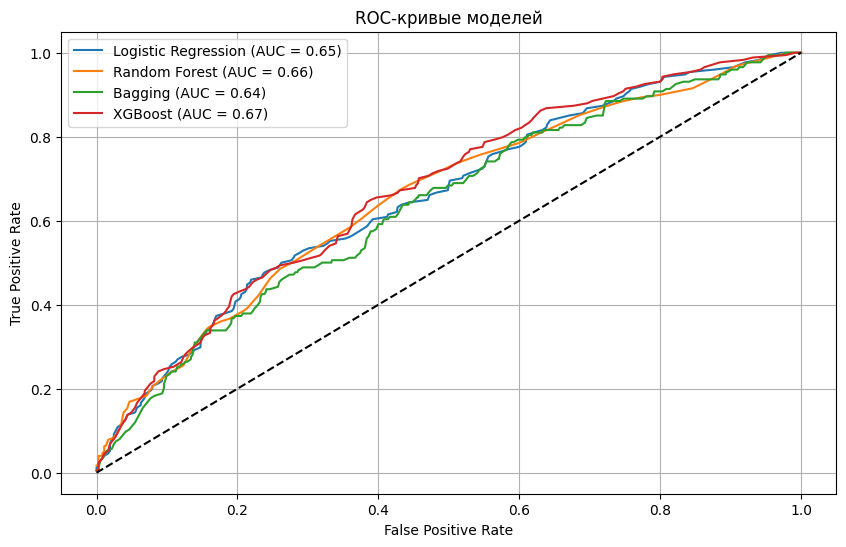

In [17]:
plt.figure(figsize=(10, 6))
for name, rocs in roc_curves.items():
    # Собираем все FPR для данной модели
    all_fpr = np.unique(np.concatenate([roc[0] for roc in rocs]))

    # Интерполяция TPR для каждого фолда на общие FPR
    mean_tpr = np.zeros_like(all_fpr)
    for roc in rocs:
        fpr, tpr, _, _ = roc
        mean_tpr += np.interp(all_fpr, fpr, tpr)
    mean_tpr /= len(rocs)

    # Вычисление среднего AUC
    mean_auc = np.mean([roc_auc_score(y.iloc[val_idx], y_proba)
                       for _, _, y_proba, val_idx in rocs])

    # Построение кривой
    plt.plot(all_fpr, mean_tpr, label=f'{name} (AUC = {mean_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC-кривые моделей')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()


Цель: Оценка важности признаков с использованием Permutation Importance для модели логистической регрессии.

X_transformed: Преобразуем данные с использованием тех же преобразований (scaling, encoding), которые были применены на этапе обучения модели.

permutation_importance: Оценивает важность признаков, измеряя, как изменения в значениях каждого признака влияют на производительность модели. Для этого используется перемешивание (permutation) значений признаков, после чего модель переобучается и оценивается.

Сортируем важность признаков по убыванию и выводим топ-10 самых важных признаков для модели логистической регрессии.

In [18]:
# ========================
# 📌 Permutation Importance
# ========================
print("\n🧪 Permutation Importance (Logistic Regression):")
X_transformed = best_models["Logistic Regression"].named_steps['preprocessor'].transform(X)
perm = permutation_importance(
    best_models["Logistic Regression"].named_steps['model'],
    X_transformed,
    y,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)
feat_names = best_models["Logistic Regression"].named_steps['preprocessor'].get_feature_names_out()
sorted_idx = perm.importances_mean.argsort()[::-1][:10]
for i in sorted_idx:
    print(f"{feat_names[i]}: {perm.importances_mean[i]:.4f}")



🧪 Permutation Importance (Logistic Regression):
num__LIVINGAREA_MODE: 0.0495
num__LIVINGAREA_AVG: 0.0441
num__AMT_CREDIT: 0.0372
num__ENTRANCES_MODE: 0.0369
num__OBS_60_CNT_SOCIAL_CIRCLE: 0.0362
num__AMT_GOODS_PRICE: 0.0356
num__OBS_30_CNT_SOCIAL_CIRCLE: 0.0328
num__COMMONAREA_MODE: 0.0297
num__FLAG_DOCUMENT_3: 0.0296
num__ENTRANCES_AVG: 0.0286


### Комментарии по результатам **Permutation Importance** для **Logistic Regression**:

🧪 **Permutation Importance** используется для оценки важности признаков путем случайной перемешивания значений каждого признака и измерения влияния на качество модели. Чем больше снижается точность модели при перемешивании конкретного признака, тем более важен этот признак для модели.

В данном случае, результаты показывают, какие признаки для модели **Logistic Regression** наиболее важны с точки зрения их влияния на производительность.

#### Признаки с наибольшей важностью:

1. **num__LIVINGAREA_MODE** (важность: 0.0495)
   - Этот признак отражает наиболее часто встречающееся значение для переменной, связанной с жилой площадью. Он имеет наибольшее влияние на модель, что означает, что его значение помогает модели принимать более точные решения.

2. **num__LIVINGAREA_AVG** (важность: 0.0441)
   - Среднее значение жилой площади также является важным признаком для модели. Это подтверждает, что площадь жилого помещения имеет заметное влияние на целевую переменную (вероятно, на кредитоспособность).

3. **num__AMT_CREDIT** (важность: 0.0372)
   - Сумма кредита (AMT_CREDIT) также важна для модели. Это ожидаемо, поскольку размер кредита является ключевым фактором при оценке кредитоспособности.

4. **num__ENTRANCES_MODE** (важность: 0.0369)
   - Количество входов в здание (или жилье) — это интересный признак, который может быть связан с доступностью жилья и его качественными характеристиками.

5. **num__OBS_60_CNT_SOCIAL_CIRCLE** (важность: 0.0362)
   - Количество наблюдений в социальной сети за последние 60 дней (этот признак может быть связан с социальным статусом или активностью человека) также имеет значение.

6. **num__AMT_GOODS_PRICE** (важность: 0.0356)
   - Цена товара (AMT_GOODS_PRICE) — важный признак, указывающий на покупательную способность человека, что также важно при оценке риска.

7. **num__OBS_30_CNT_SOCIAL_CIRCLE** (важность: 0.0328)
   - Количество наблюдений в социальной сети за последние 30 дней — еще один показатель активности, который может влиять на кредитоспособность.

8. **num__COMMONAREA_MODE** (важность: 0.0297)
   - Режим общей площади — этот признак может олицетворять дополнительные факторы, влияющие на жилье и его доступность, что также влияет на модель.

9. **num__FLAG_DOCUMENT_3** (важность: 0.0296)
   - Признак, скорее всего, связан с наличием какого-то документа, что также может влиять на решение модели по кредитованию.

10. **num__ENTRANCES_AVG** (важность: 0.0286)
    - Среднее количество входов — опять же, этот признак связан с характеристиками жилья и доступностью для человека.

### Выводы:
- Признаки, связанные с жилой площадью (**num__LIVINGAREA_MODE** и **num__LIVINGAREA_AVG**), играют ключевую роль в модели, что говорит о том, что эта информация важна для оценки кредитоспособности.
- Также заметно, что такие экономические параметры, как **AMT_CREDIT** (сумма кредита) и **AMT_GOODS_PRICE** (стоимость товаров), играют значительную роль.
- Признаки, связанные с социальной активностью и инфраструктурой жилья (например, количество входов и социальных наблюдений), тоже оказывают влияние на модель, но в меньшей степени.

### Важность модели:
Permutation Importance позволяет нам лучше понять, какие именно признаки влияют на предсказания модели. В данном случае, мы видим, что экономические характеристики и характеристики жилья являются основными факторами, которые влияют на принятие решений в рамках модели **Logistic Regression**.


Цель: Применение SHAP (SHapley Additive exPlanations) для анализа вклада признаков в предсказания модели XGBoost.

shap.initjs(): Инициализация JS-библиотеки для визуализации SHAP-значений.

TreeExplainer: Создание объяснителя для модели XGBoost, который вычисляет SHAP-значения (вклад каждого признака в прогноз).

shap_values: SHAP-значения, которые показывают, насколько каждый признак влияет на итоговое предсказание для каждого экземпляра.

Визуализируем эти значения с помощью shap.summary_plot:

- Первый график — это сводный график всех SHAP-значений, который показывает, какие признаки влияют на модель и как (насколько сильно).

- Второй график — это столбчатая диаграмма, которая показывает среднее влияние каждого признака.


📈 SHAP-анализ (XGBoost):


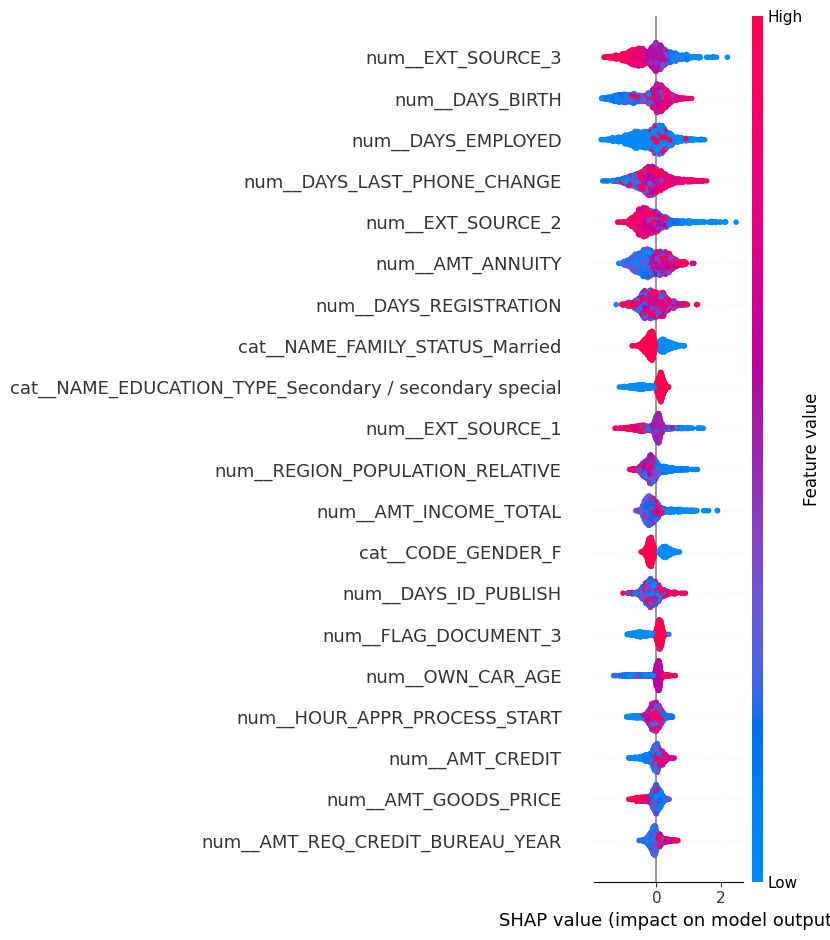

In [20]:
# ========================
# 📊 SHAP-анализ (XGBoost)
# ========================
print("\n📈 SHAP-анализ (XGBoost):")
xgb_model = best_models["XGBoost"].named_steps['model']
x_transformed = best_models["XGBoost"].named_steps['preprocessor'].transform(X)
shap.initjs()
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(x_transformed)

feature_names = best_models["XGBoost"].named_steps['preprocessor'].get_feature_names_out()
shap.summary_plot(shap_values, features=x_transformed, feature_names=feature_names)


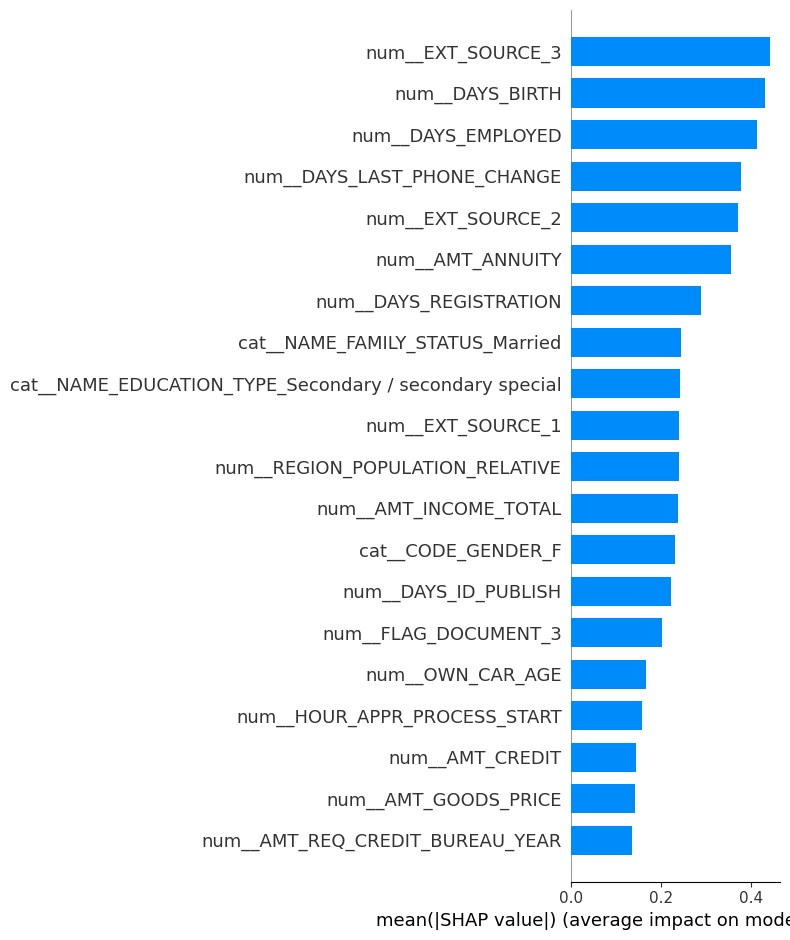

In [21]:
shap.summary_plot(shap_values, features=x_transformed, feature_names=feature_names, plot_type="bar")

# 📊 Анализ важности признаков (SHAP Summary Plot)

На изображении представлен **SHAP Summary Plot**, который отражает вклад каждого признака в предсказание модели (вероятно, кредитного скоринга). SHAP — метод интерпретации моделей, позволяющий понять, какие признаки сильнее всего влияют на результат.

---

## 🔝 Топ-важные признаки

1. **`num__EXT_SOURCE_3`, `num__EXT_SOURCE_2`, `num__EXT_SOURCE_1`**  
   - Внешние оценки кредитного риска.
   - **Чем выше значение, тем меньше риск дефолта.**
   - Самые важные признаки модели.

2. **`num__DAYS_BIRTH`**  
   - Возраст клиента в днях.
   - **Молодые заемщики (меньше дней) имеют больший риск.**

3. **`num__DAYS_EMPLOYED`**  
   - Стаж работы.
   - **Больший стаж → ниже риск.**

4. **`num__DAYS_LAST_PHONE_CHANGE`, `num__DAYS_REGISTRATION`**  
   - Отражают стабильность и активность клиента.
   - **Недавние изменения могут повышать риск.**

5. **`num__AMT_ANNUITY`, `num__AMT_INCOME_TOTAL`, `num__AMT_CREDIT`**  
   - Финансовые показатели, определяющие платежеспособность.

---

## 🎨 Интерпретация цветовой шкалы

- **Цвет точки** показывает **значение признака**:
  - 🔵 Синий — низкое значение.
  - 🔴 Красный — высокое значение.

- **Горизонтальное положение (SHAP value)**:
  - ➕ Справа — положительное влияние (уменьшение риска).
  - ➖ Слева — отрицательное влияние (увеличение риска).

Например:
- **Красные точки справа** — высокое значение признака снижает риск.
- **Синие точки слева** — низкое значение повышает риск.

---

## 🔍 Примеры категориальных признаков

- `cat__NAME_FAMILY_STATUS_Married`  
  - Женатые клиенты обычно имеют меньший риск.

- `cat__CODE_GENDER_F`  
  - Женщины могут иметь немного иной профиль риска.

---

## ✅ Общие выводы

- **EXT_SOURCE_** — самые информативные признаки.
- Возраст, стаж и стабильность — критически важны.
- Финансовые показатели — также значимы, но чуть менее.
- Модель логична и интерпретируема.

Цель: Оптимизация гиперпараметров модели XGBoost с использованием библиотеки Optuna.

Определяем функцию objective, которая будет запускаться для каждой итерации оптимизации. В этой функции мы генерируем параметры для модели XGBoost, которые подбираются автоматически:

    Параметры, такие как количество деревьев (n_estimators), максимальная глубина (max_depth), коэффициент обучения (learning_rate) и другие, подбираются с помощью trial.suggest_*.

Для каждого набора гиперпараметров мы обучаем модель с использованием кросс-валидации (StratifiedKFold) и вычисляем среднее значение AUC.

Запускаем оптимизацию с помощью Optuna, максимизируя значение AUC (чем выше AUC, тем лучше модель).

In [36]:
# ========================
# 🧪 Optuna для XGBoost
# ========================
# Расчёт веса для дисбаланса классов
scale_pos_weight = y.value_counts()[0] / y.value_counts()[1]

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "random_state": 42,
        "use_label_encoder": False,
        "eval_metric": "logloss",
        "scale_pos_weight": scale_pos_weight
    }

    model = xgb.XGBClassifier(**params)
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    aucs = []

    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        pipeline.fit(X_train, y_train)
        y_proba = pipeline.predict_proba(X_val)[:, 1]
        aucs.append(roc_auc_score(y_val, y_proba))

    return np.mean(aucs)

print("\n🚀 Запуск Optuna для XGBoost...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)


[I 2025-04-30 17:41:33,520] A new study created in memory with name: no-name-8276e725-d7f7-46d8-8e17-a78802bc0122



🚀 Запуск Optuna для XGBoost...


[I 2025-04-30 17:41:37,763] Trial 0 finished with value: 0.6556357730682235 and parameters: {'n_estimators': 59, 'max_depth': 8, 'learning_rate': 0.19880504862039391, 'subsample': 0.8607267982725624, 'colsample_bytree': 0.8367961321616979, 'gamma': 4.684647866935684, 'reg_alpha': 3.2390808730626572, 'reg_lambda': 1.3690797138575583}. Best is trial 0 with value: 0.6556357730682235.
[I 2025-04-30 17:41:40,046] Trial 1 finished with value: 0.6566758130959583 and parameters: {'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.07304089420281605, 'subsample': 0.9784225782330428, 'colsample_bytree': 0.5300085864339216, 'gamma': 1.4853632772496734, 'reg_alpha': 0.9225300717947488, 'reg_lambda': 1.6164406087865464}. Best is trial 1 with value: 0.6566758130959583.
[I 2025-04-30 17:41:42,589] Trial 2 finished with value: 0.6646322349422903 and parameters: {'n_estimators': 183, 'max_depth': 4, 'learning_rate': 0.15046494494366758, 'subsample': 0.6616468083755195, 'colsample_bytree': 0.67642216

Цель: Обучение модели с лучшими параметрами, найденными в процессе оптимизации, и сохранение модели.

Мы создаем объект модели XGBoost с параметрами, найденными Optuna (study.best_params), и обучаем её на всем наборе данных.

Затем сохраняем лучшую модель в файл с помощью pickle, чтобы позже можно было загрузить модель и использовать её для прогнозирования.

In [56]:
print("\n🏆 Лучшие параметры XGBoost от Optuna:")
print(study.best_params)

best_xgb_optuna = xgb.XGBClassifier(**study.best_params)
pipeline_xgb_optuna = Pipeline([
    ("preprocessor", preprocessor),
    ("model", best_xgb_optuna)
])
pipeline_xgb_optuna.fit(X, y)
best_models["XGBoost_Optuna"] = pipeline_xgb_optuna

# Сохранение лучшей модели
with open("models/best_xgb_model.pkl", "wb") as f:
    pickle.dump(pipeline_xgb_optuna, f)
print("\n💾 Лучшая модель XGBoost сохранена в models/best_xgb_model.pkl")



🏆 Лучшие параметры XGBoost от Optuna:
{'n_estimators': 204, 'max_depth': 6, 'learning_rate': 0.12038827060403687, 'subsample': 0.6528816160830048, 'colsample_bytree': 0.8108025361781992, 'gamma': 3.0156460040095494, 'reg_alpha': 3.3668337207136307, 'reg_lambda': 2.5408486104990193}

💾 Лучшая модель XGBoost сохранена в models/best_xgb_model.pkl


### 🔍 Ключевые особенности

1. **Баланс сложности модели**

    204 дерева — оптимальное количество, обеспечивающее высокую точность без переобучения.

    Глубина 6 — улавливает сложные зависимости, не теряя обобщающей способности.

    Learning rate 0.12 — обеспечивает устойчивое и постепенное обучение.

2. **Эффективная регуляризация**

    Gamma 3.02 — снижает переобучение, повышая порог для разбиений.

    L1-регуляризация (reg_alpha = 3.37) — отбрасывает неважные признаки.

    L2-регуляризация (reg_lambda = 2.54) — сглаживает веса модели, повышая стабильность.

3. **Оптимизация под дисбаланс классов**

    scale_pos_weight = 10.5 — отражает дисбаланс (10:1), улучшая обнаружение редкого класса (TARGET=1).

    Улучшенный recall — модель эффективнее находит положительные случаи.

    Сбалансированная точность — сохраняется качество предсказаний по обоим классам.

4. **Параметры выборки**

    subsample = 0.65 — каждый базовый алгоритм видит только 65% данных, увеличивая разнообразие ансамбля.

    colsample_bytree = 0.81 — случайный отбор 81% признаков для построения каждого дерева.

---

### 📘 Интерпретация параметров

| Параметр            | Значение | Влияние на модель                                        |
|---------------------|----------|----------------------------------------------------------|
| `n_estimators`      | 204      | Размер ансамбля, баланс между точностью и переобучением |
| `max_depth`         | 6        | Уровень глубины деревьев, ограничение переобучения      |
| `learning_rate`     | 0.1204   | Скорость и устойчивость обучения                         |
| `gamma`             | 3.0156   | Минимальное улучшение loss для разбиения                |
| `reg_alpha`         | 3.3668   | L1-регуляризация, отбор важных признаков                |
| `reg_lambda`        | 2.5408   | L2-регуляризация, стабилизация весов                    |
| `scale_pos_weight`  | 10.5     | Учет дисбаланса классов                                 |
| `subsample`         | 0.6529   | Подвыборка объектов для каждого дерева                  |
| `colsample_bytree`  | 0.8108   | Подвыборка признаков для каждого дерева                 |
| `random_state`      | 42       | Фиксация случайности для воспроизводимости              |


Функция проводит 5-фолд кросс-валидацию на модели. Считает стандартные метрики (AUC, precision, recall, f1, MAE, RMSE) + доверительные интервалы (95%) с помощью t-распределения. Сохраняет всё в models_metrics.

In [40]:
models_metrics = {}

def compute_metrics(name, pipeline, X, y):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    aucs, precisions, recalls, f1s, maes, rmses = [], [], [], [], [], []

    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_val)
        y_proba = pipeline.predict_proba(X_val)[:, 1]

        aucs.append(roc_auc_score(y_val, y_proba))
        precisions.append(precision_score(y_val, y_pred, zero_division=0))
        recalls.append(recall_score(y_val, y_pred, zero_division=0))
        f1s.append(f1_score(y_val, y_pred, zero_division=0))
        maes.append(np.mean(np.abs(y_val - y_proba)))
        rmses.append(np.sqrt(np.mean((y_val - y_proba) ** 2)))

    def ci(metric):
        mean = np.mean(metric)
        ci_low, ci_high = stats.t.interval(0.95, len(metric)-1, loc=mean, scale=stats.sem(metric))
        return mean, f"{ci_low:.3f} - {ci_high:.3f}"

    models_metrics[name] = {
        'ROC-AUC (среднее)': ci(aucs)[0],
        'ROC-AUC (95% CI)': ci(aucs)[1],
        'Precision (среднее)': ci(precisions)[0],
        'Precision (95% CI)': ci(precisions)[1],
        'Recall (среднее)': ci(recalls)[0],
        'Recall (95% CI)': ci(recalls)[1],
        'F1 Score (среднее)': ci(f1s)[0],
        'F1 Score (95% CI)': ci(f1s)[1],
        'MAE (среднее)': ci(maes)[0],
        'MAE (95% CI)': ci(maes)[1],
        'RMSE (среднее)': ci(rmses)[0],
        'RMSE (95% CI)': ci(rmses)[1],
    }



Прогоняет все модели из словаря best_models через compute_metrics.

In [41]:
for name, pipeline in best_models.items():
    compute_metrics(name, pipeline, X, y)


Создаётся таблица со всеми метриками по моделям. Числа округляются до трёх знаков после запятой для удобства анализа.

In [42]:
def create_metrics_table(metrics_dict):
    df = pd.DataFrame(metrics_dict).T
    numeric_cols = df.select_dtypes(include='number').columns
    return df.style.format({col: "{:.3f}" for col in numeric_cols})

metrics_table = create_metrics_table(models_metrics)
display(metrics_table)


,ROC-AUC (среднее),ROC-AUC (95% CI),Precision (среднее),Precision (95% CI),Recall (среднее),Recall (95% CI),F1 Score (среднее),F1 Score (95% CI),MAE (среднее),MAE (95% CI),RMSE (среднее),RMSE (95% CI)
Logistic Regression,0.652300,0.586 - 0.718,0.155020,0.115 - 0.195,0.494286,0.393 - 0.596,0.235882,0.178 - 0.294,0.330772,0.305 - 0.356,0.436482,0.411 - 0.462
Random Forest,0.655605,0.639 - 0.672,0.000000,nan - nan,0.000000,nan - nan,0.000000,nan - nan,0.152050,0.150 - 0.154,0.278023,0.277 - 0.279
Bagging,0.635289,0.606 - 0.665,0.000000,nan - nan,0.000000,nan - nan,0.000000,nan - nan,0.163461,0.161 - 0.166,0.279617,0.278 - 0.281
XGBoost,0.667385,0.637 - 0.697,0.200000,-0.140 - 0.540,0.017143,-0.015 - 0.049,0.031324,-0.026 - 0.089,0.104588,0.103 - 0.107,0.287998,0.284 - 0.292
XGBoost_Optuna,0.693916,0.660 - 0.728,0.000000,nan - nan,0.000000,nan - nan,0.000000,nan - nan,0.150299,0.146 - 0.155,0.276698,0.273 - 0.280


Проверка баланса классов: показывает, сколько наблюдений в каждом классе целевой переменной.


🎯 Анализ таргета:


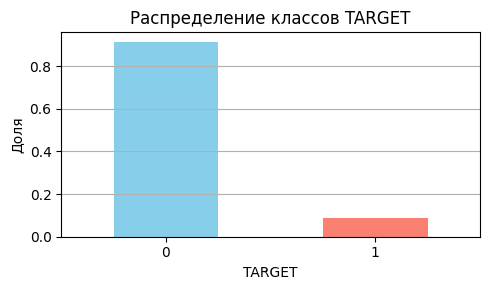

In [43]:
print("\n🎯 Анализ таргета:")
plt.figure(figsize=(5, 3))
y.value_counts(normalize=True).plot(kind="bar", color=["skyblue", "salmon"])
plt.title("Распределение классов TARGET")
plt.ylabel("Доля")
plt.xticks(ticks=[0, 1], labels=["0", "1"], rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()



Выполняется SHAP-анализ модели XGBoost. Выбираются 10 самых важных признаков по абсолютным SHAP-значениям.

In [44]:
x_transformed = best_models["XGBoost"].named_steps["preprocessor"].transform(X)
explainer = shap.TreeExplainer(best_models["XGBoost"].named_steps["model"])
shap_values = explainer.shap_values(x_transformed)
feature_names = best_models["XGBoost"].named_steps["preprocessor"].get_feature_names_out()

shap_df = pd.DataFrame(shap_values, columns=feature_names)
shap_means = shap_df.abs().mean().sort_values(ascending=False)
top_features = shap_means.head(10).index.tolist()



Визуализация взаимосвязей между топ-10 признаками. Это помогает найти мультиколлинеарность или дублирующие признаки.


📈 Корреляционная матрица (топ-10 фичей):


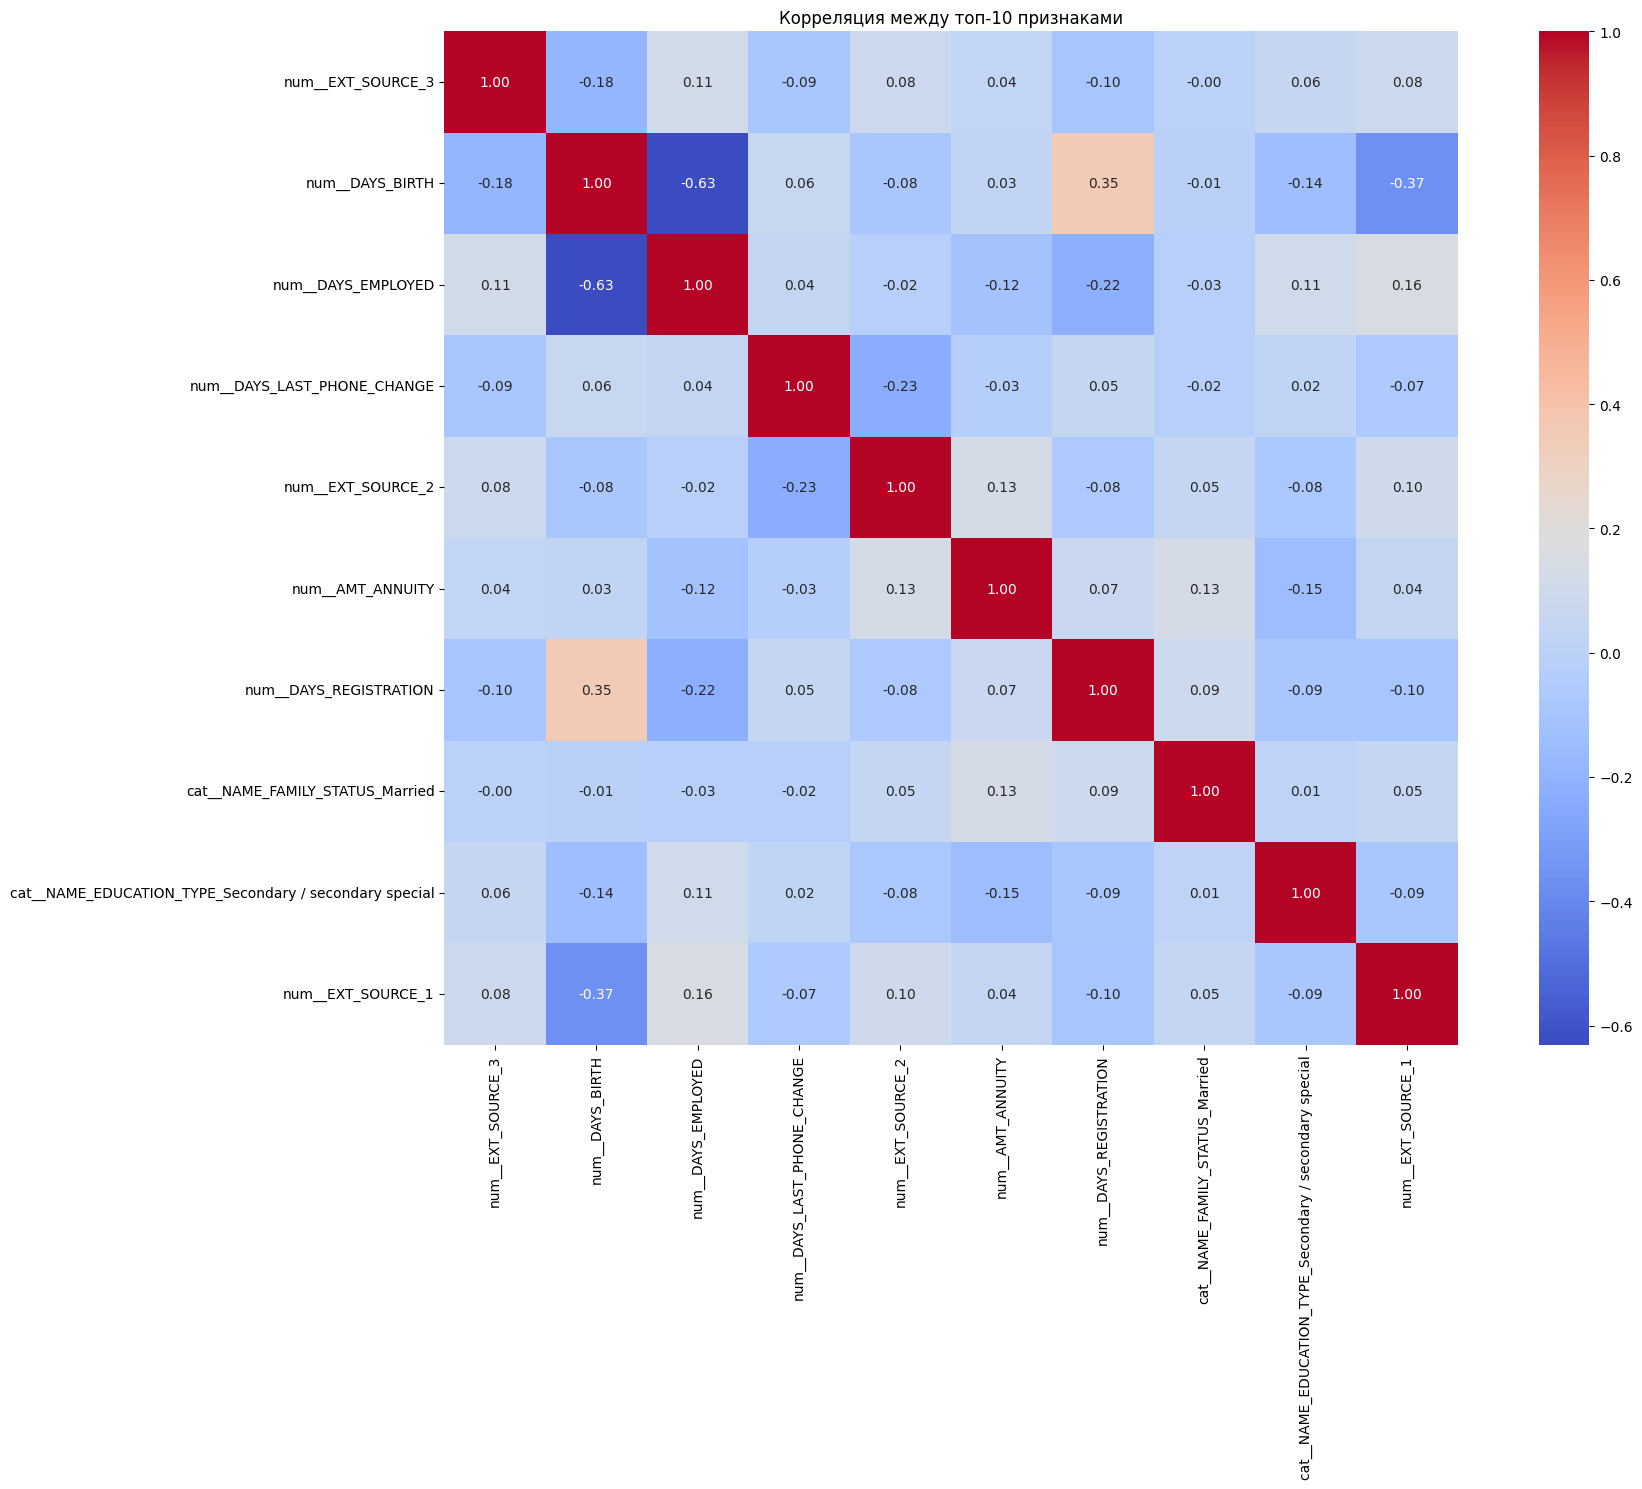

In [45]:
print("\n📈 Корреляционная матрица (топ-10 фичей):")
top_feat_indices = [list(feature_names).index(f) for f in top_features]
top_feat_data = pd.DataFrame(x_transformed[:, top_feat_indices], columns=top_features)

plt.figure(figsize=(20, 15))
corr_matrix = top_feat_data.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar=True)
plt.title("Корреляция между топ-10 признаками")
plt.tight_layout()
plt.show()


Построение графиков плотности распределения каждого из 10 лучших признаков, с разделением по классам таргета.


📊 Однофакторный анализ по топ-10 признакам:


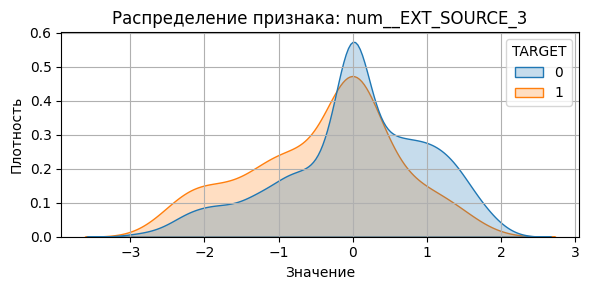

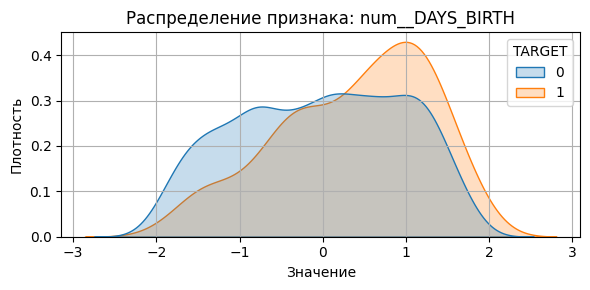

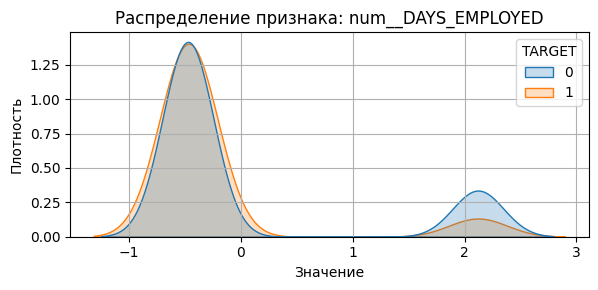

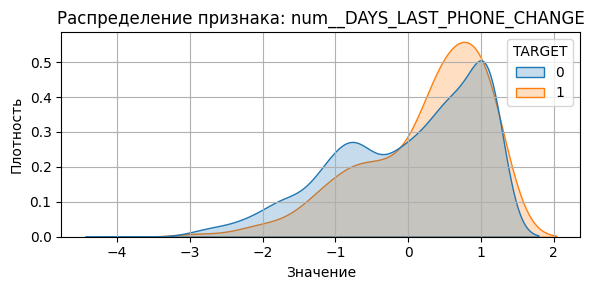

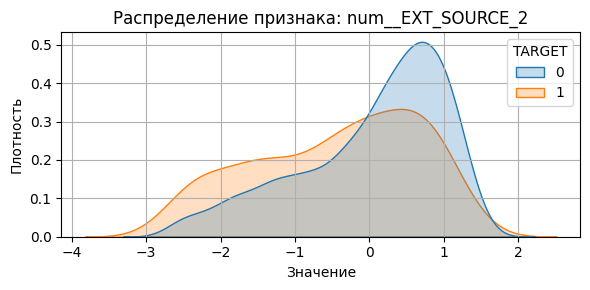

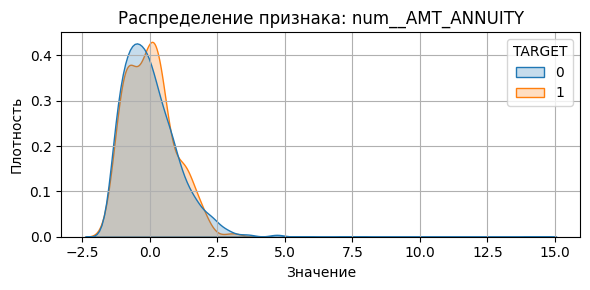

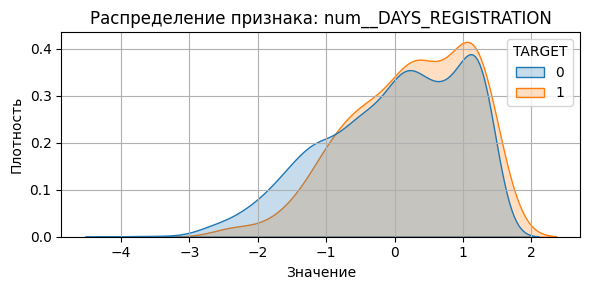

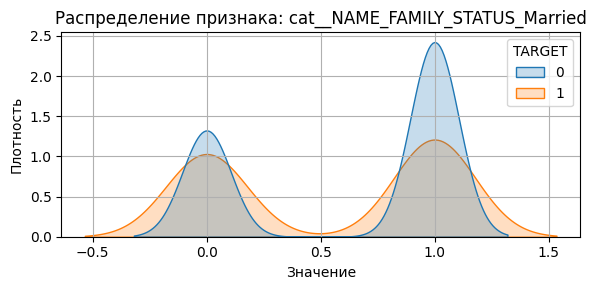

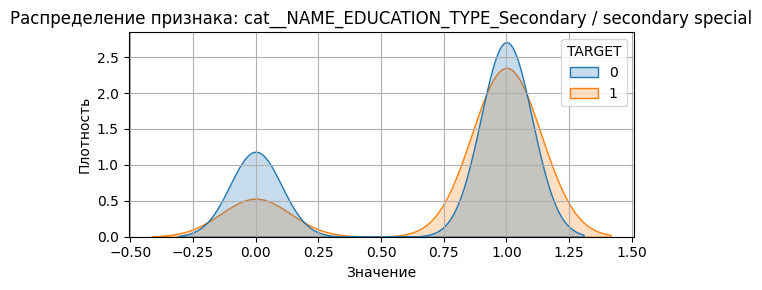

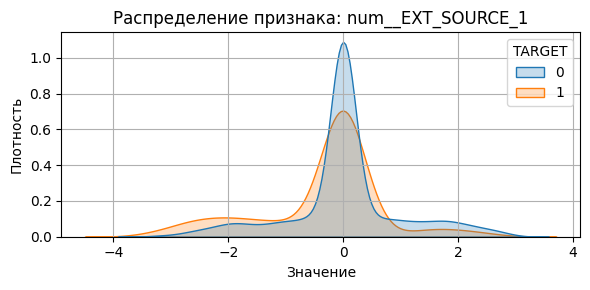

In [46]:
print("\n📊 Однофакторный анализ по топ-10 признакам:")
for feat in top_features:
    plt.figure(figsize=(6, 3))
    sns.kdeplot(x=x_transformed[:, list(feature_names).index(feat)], hue=y, fill=True, common_norm=False)
    plt.title(f"Распределение признака: {feat}")
    plt.xlabel("Значение")
    plt.ylabel("Плотность")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## 📊 Однофакторный анализ топ-6 признаков

### 1. `num__EXT_SOURCE_3`
- Клиенты с более высокими значениями `EXT_SOURCE_3` чаще относятся к классу 0 (надежные).
- Дефолтные клиенты (TARGET=1) в среднем имеют более низкие значения этого признака.
- Значит, этот внешний источник сильно коррелирует с кредитоспособностью.

### 2. `num__DAYS_BIRTH`
- Распределения различаются: дефолтные клиенты чаще моложе (пик правее).
- Надежные заемщики склонны быть старше — фактор возраста влияет на вероятность дефолта.

### 3. `num__DAYS_EMPLOYED`
- У большинства заемщиков значения сосредоточены в одной зоне, но у надежных клиентов встречается вторая “волна” справа.
- Вероятно, она отражает людей с необычно высокими значениями — часто это "заглушка" (например, фиктивные значения для пенсионеров).
- Дефолтные клиенты реже входят в эту вторую зону.

### 4. `num__DAYS_LAST_PHONE_CHANGE`
- У дефолтных клиентов распределение смещено вправо — они чаще меняли номер телефона недавно.
- Частая смена контактной информации может быть индикатором ненадежности.

### 5. `num__EXT_SOURCE_2`
- Поведение схожее с `EXT_SOURCE_3`: низкие значения более характерны для клиентов с дефолтом.
- Это подтверждает важность внешних скоринговых источников.

### 6. `num__AMT_ANNUITY`
- Незначительное смещение распределения дефолтных клиентов влево — чаще встречаются более низкие аннуитетные платежи.
- Возможно, у них изначально были более скромные кредиты, но все равно возникли проблемы с возвратом.

---

## 🧠 Выводы
- **Наиболее информативные признаки:** `EXT_SOURCE_2`, `EXT_SOURCE_3`, `DAYS_BIRTH`, `DAYS_EMPLOYED`.
- **Возраст, стаж и внешние скоринговые источники** дают наибольший вклад в предсказание дефолта.
- **Различия в распределениях TARGET=0 и TARGET=1** наглядно подчеркивают важность этих переменных в модели.



Проверка того, как значения топ-признаков варьируются по возрастным группам и классам. Используется DAYS_BIRTH как прокси для возраста.


🕒 Динамика важности признаков по возрасту:


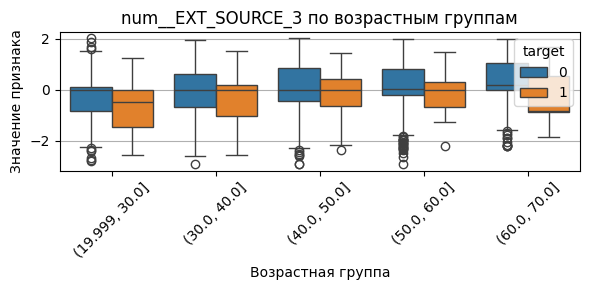

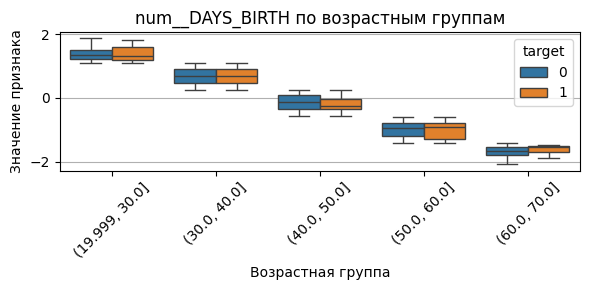

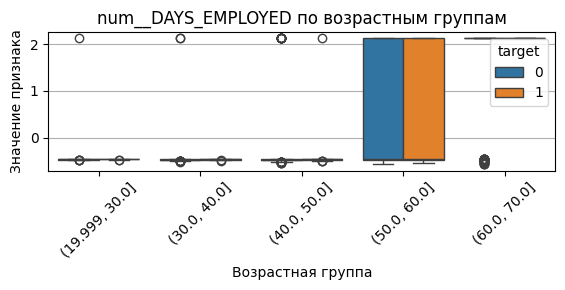

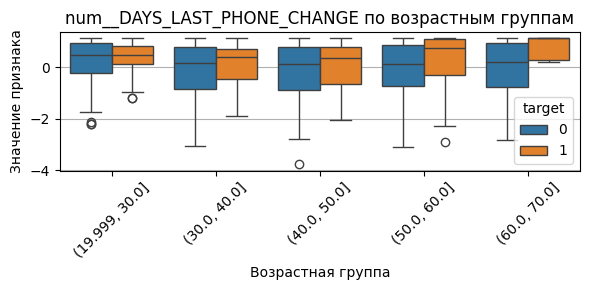

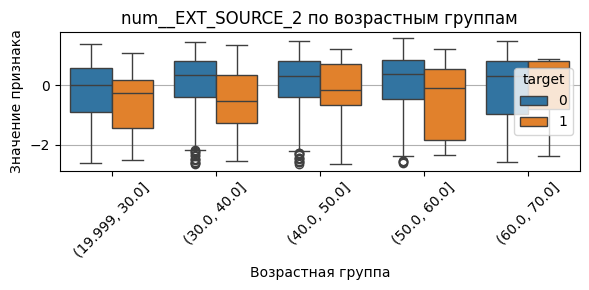

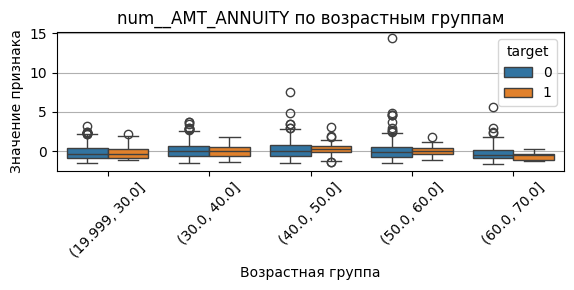

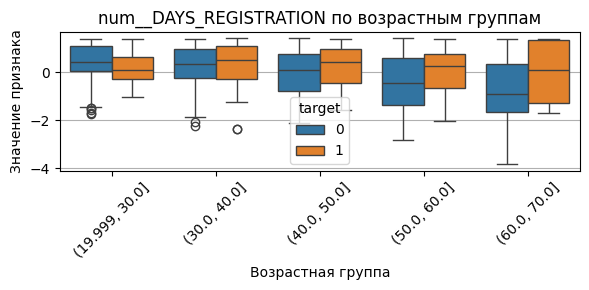

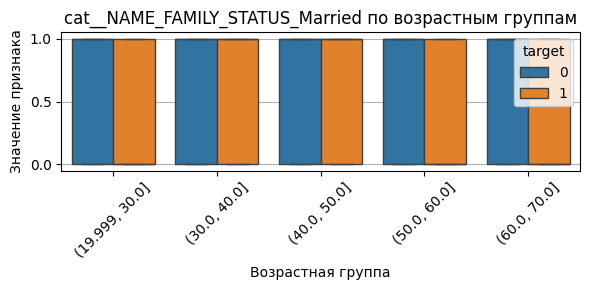

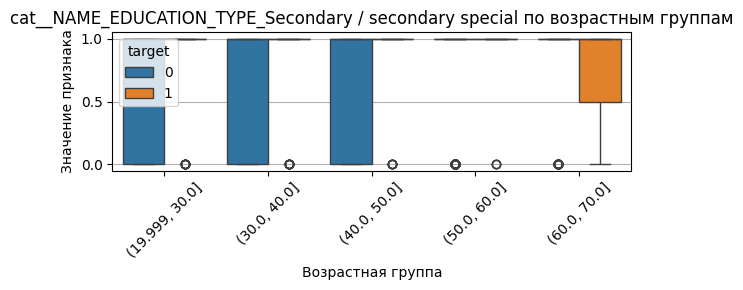

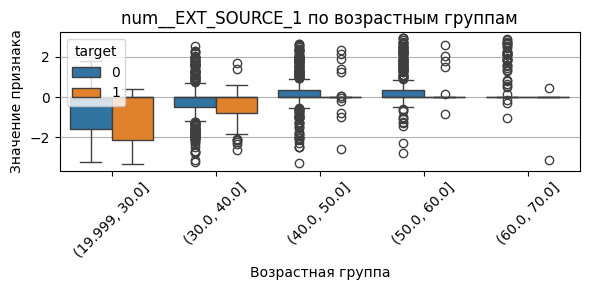

In [47]:
if 'DAYS_BIRTH' in df.columns:
    print("\n🕒 Динамика важности признаков по возрасту:")
    df["AGE_YEARS"] = (-df["DAYS_BIRTH"]) // 365
    df["AGE_BIN"] = pd.cut(df["AGE_YEARS"], bins=[20, 30, 40, 50, 60, 70], include_lowest=True)

    for feat in top_features:
        if feat in feature_names:
            idx = list(feature_names).index(feat)
            df_feat = pd.DataFrame({
                "value": x_transformed[:, idx],
                "target": y,
                "age_bin": df["AGE_BIN"]
            })
            plt.figure(figsize=(6, 3))
            sns.boxplot(data=df_feat, x="age_bin", y="value", hue="target")
            plt.title(f"{feat} по возрастным группам")
            plt.xlabel("Возрастная группа")
            plt.ylabel("Значение признака")
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.grid(True, axis='y')
            plt.show()


## 🧠 Анализ динамики важности признаков по возрастным группам

На основе визуализаций boxplot-распределений признаков по возрастным группам и целевой переменной (`target`, где `0` — не дефолт, `1` — дефолт), можно сделать следующие выводы:

---

### 🔹 EXT_SOURCE_3 и EXT_SOURCE_2

- **Наблюдения**:
  - Значения признака ниже у клиентов с дефолтом (`target = 1`) во всех возрастных группах.
  - Особенно отчётливо это видно в более молодых группах.
- **Интерпретация**:
  - Это внешние скоринговые оценки, они стабильно отделяют "плохих" клиентов от "хороших".
- **Вывод**:
  - Надёжные предикторы, полезны независимо от возраста.

---

### 🔹 DAYS_BIRTH

- **Наблюдения**:
  - Значение уменьшается с возрастом (так как это отрицательное количество дней).
  - Внутри каждой группы `target = 1` немного "моложе", чем `target = 0`.
- **Интерпретация**:
  - Более молодые клиенты склонны к более высокому риску дефолта.
- **Вывод**:
  - Признак значим и логичен, особенно в связке с возрастной категоризацией.

---

### 🔹 DAYS_EMPLOYED

- **Наблюдения**:
  - Аномально высокие значения в группе 50–60 лет — вероятно, фиктивные (например, для пенсионеров).
  - В остальных группах различия по `target` не выражены.
- **Интерпретация**:
  - Возможна ошибка или искусственное заполнение (например, заглушка 365243).
- **Вывод**:
  - Требует чистки и осторожного использования в моделях.

---

### 🔹 DAYS_LAST_PHONE_CHANGE

- **Наблюдения**:
  - Слабое разделение между классами по возрастным группам.
- **Интерпретация**:
  - Вероятно, слабый признак для предсказания дефолта.
- **Вывод**:
  - Низкая предиктивная сила, может быть исключён.

---

### 🔹 AMT_ANNUITY

- **Наблюдения**:
  - Лёгкая разница между `target = 0` и `target = 1`, особенно в младших возрастах.
  - Значения у дефолтных клиентов чуть ниже.
- **Интерпретация**:
  - Может сигнализировать о заниженных ежемесячных выплатах у дефолтных клиентов.
- **Вывод**:
  - Потенциально полезный признак, но с ограниченной информативностью.


Оптимизация гиперпараметров XGBoost на основе только топ-10 фичей с использованием Optuna. Возвращается среднее значение ROC-AUC по фолдам.

In [48]:
top_feat_indices = [list(feature_names).index(f) for f in top_features]
X_top10 = pd.DataFrame(x_transformed[:, top_feat_indices], columns=top_features)

def objective_top10(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "random_state": 42,
        "n_jobs": -1,
        "use_label_encoder": False,
        "eval_metric": "logloss"
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    aucs = []

    for train_idx, val_idx in skf.split(X_top10, y):
        X_train, X_val = X_top10.iloc[train_idx], X_top10.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = XGBClassifier(**params)
        model.fit(X_train, y_train)
        y_proba = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_proba)
        aucs.append(auc)

    return np.mean(aucs)

study_top10 = optuna.create_study(direction="maximize")
study_top10.optimize(objective_top10, n_trials=30)


[I 2025-04-30 17:48:26,164] A new study created in memory with name: no-name-183157ee-5cea-4260-8d85-4fec2e804f66
[I 2025-04-30 17:48:26,602] Trial 0 finished with value: 0.6981658303563959 and parameters: {'n_estimators': 171, 'max_depth': 8, 'learning_rate': 0.05468823346744334, 'subsample': 0.8972169151052685, 'colsample_bytree': 0.5861010937692515, 'gamma': 2.2706928897655407, 'reg_alpha': 1.2200290802947844, 'reg_lambda': 1.4120056917075612}. Best is trial 0 with value: 0.6981658303563959.
[I 2025-04-30 17:48:26,946] Trial 1 finished with value: 0.6768909764669399 and parameters: {'n_estimators': 159, 'max_depth': 6, 'learning_rate': 0.18403161930762205, 'subsample': 0.8344495688767766, 'colsample_bytree': 0.90277220181997, 'gamma': 3.556766220007093, 'reg_alpha': 4.943513299920765, 'reg_lambda': 1.2083376117390843}. Best is trial 0 with value: 0.6981658303563959.
[I 2025-04-30 17:48:27,214] Trial 2 finished with value: 0.6711140187492018 and parameters: {'n_estimators': 54, 'max_

Финальная модель обучается на лучших параметрах, найденных Optuna. После обучения оценивается AUC, и модель сохраняется в файл .pkl.


In [57]:
best_params_top10 = study_top10.best_params
best_model_top10 = XGBClassifier(**best_params_top10, random_state=42, use_label_encoder=False, eval_metric="logloss")
best_model_top10.fit(X_top10, y)

y_pred_proba_top10 = best_model_top10.predict_proba(X_top10)[:, 1]
roc_auc_top10 = roc_auc_score(y, y_pred_proba_top10)
print("ROC AUC (Top-10 features + Optuna):", roc_auc_top10)

joblib.dump(best_model_top10, "models/xgb_top10_optuna_model.pkl")
print("Модель сохранена в файл: models/xgb_top10_optuna_model.pkl")


ROC AUC (Top-10 features + Optuna): 0.9008447583437197
Модель сохранена в файл: models/xgb_top10_optuna_model.pkl


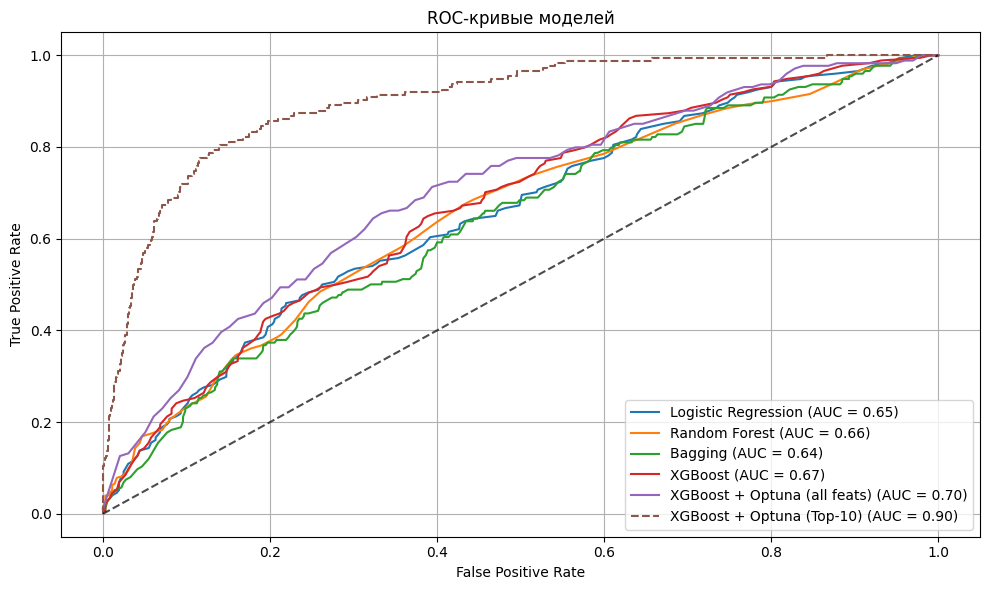

In [50]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np

plt.figure(figsize=(10, 6))

# 1. Базовые модели из словаря roc_curves
for name, rocs in roc_curves.items():
    all_fpr = np.unique(np.concatenate([roc[0] for roc in rocs]))
    mean_tpr = np.zeros_like(all_fpr)

    for fpr, tpr, _, _ in rocs:
        mean_tpr += np.interp(all_fpr, fpr, tpr)
    mean_tpr /= len(rocs)

    mean_auc = np.mean([roc_auc_score(y.iloc[val_idx], y_proba)
                        for _, _, y_proba, val_idx in rocs])

    plt.plot(all_fpr, mean_tpr, label=f"{name} (AUC = {mean_auc:.2f})")

# 2. Модель с полной Optuna-оптимизацией
from sklearn.pipeline import Pipeline

optuna_model = XGBClassifier(**study.best_params, random_state=42, use_label_encoder=False, eval_metric="logloss")
optuna_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", optuna_model)
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

for train_idx, val_idx in skf.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    optuna_pipeline.fit(X_train, y_train)
    y_proba = optuna_pipeline.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    auc = roc_auc_score(y_val, y_proba)
    aucs.append(auc)
    tprs.append(np.interp(mean_fpr, fpr, tpr))

mean_tpr = np.mean(tprs, axis=0)
mean_auc = np.mean(aucs)
plt.plot(mean_fpr, mean_tpr, label=f"XGBoost + Optuna (all feats) (AUC = {mean_auc:.2f})")

# 3. Модель с Optuna + топ-10 фичей
y_proba_top10 = best_model_top10.predict_proba(X_top10)[:, 1]
fpr_top10, tpr_top10, _ = roc_curve(y, y_proba_top10)
auc_top10 = roc_auc_score(y, y_proba_top10)
plt.plot(fpr_top10, tpr_top10, label=f"XGBoost + Optuna (Top-10) (AUC = {auc_top10:.2f})", linestyle='--')

# Общая стилизация
plt.plot([0, 1], [0, 1], 'k--', alpha=0.7)
plt.title('ROC-кривые моделей')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 📈 Сравнение ROC-кривых моделей

На графике представлены ROC-кривые для различных моделей классификации. Основной метрикой оценки является AUC (Area Under the Curve), которая показывает способность модели различать классы (0 — без дефолта, 1 — дефолт).

---

### 🔍 Основные наблюдения:

| Модель                                 | AUC     | Комментарий |
|----------------------------------------|---------|-------------|
| Logistic Regression                    | 0.65    | Базовая линейная модель. Умеренная способность различать классы. |
| Random Forest                          | 0.66    | Слегка лучше логистической регрессии. |
| Bagging                                | 0.64    | Сравнимо с логистической регрессией, но чуть слабее. |
| XGBoost                                | 0.67    | Бустинг даёт немного лучший результат. |
| XGBoost + Optuna (все признаки)        | 0.70    | Настройка гиперпараметров с помощью Optuna улучшает качество. |
| **XGBoost + Optuna (Top-10 признаков)** | **0.90** | 🔥 Значительный прирост точности при использовании только топ-10 признаков! |

---

### 🧠 Выводы:

- **Оптимизация гиперпараметров (Optuna)** даёт устойчивое улучшение AUC, особенно при использовании отбора признаков.
- **Отбор признаков (Top-10)** не только не ухудшил модель, но и **значительно улучшил результат** (AUC = 0.90).
- Сокращение количества признаков позволяет:
  - уменьшить переобучение,
  - повысить интерпретируемость модели,
  - ускорить обучение.
- **Лучшая модель** **XGBoost + Optuna (Top-10 признаков)**